In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_parquet("../data/LSTM_DATA_WITH_PRICE.parquet")

In [3]:
data.describe()

,moneyness,time_to_expiry,Micro_Price_Imbalance,BSM_Mispricing,Up_OBI,bsm_delta,Up_spread,Net_Flow_ema_60s,CVD_Net_Flow,Up_BUY_Urgency,...,macro_rv_1h,macro_return_1h,macro_return_15min,Whale_Imbalance_ma_10s,Up_price_momentum_15s,Net_OFI,Price_Discovery_Spread,Net_Nominal_Flow,Target_5s_Return,execution_price
count,450747.000000,450747.000000,450747.000000,450747.000000,450747.000000,4.507470e+05,450747.000000,450747.000000,450747.000000,450747.000000,...,450747.000000,450747.000000,450747.000000,450747.000000,450747.000000,450747.000000,450747.000000,450747.000000,450747.000000,450747.000000
mean,5.395174,443.709935,-0.000010,0.000829,0.004865,4.473456e-03,0.016015,0.504433,98.517101,0.006890,...,0.336361,0.000395,-0.000049,0.291082,0.253994,0.006016,0.013901,0.584450,0.001227,0.509190
std,129.658849,209.377443,0.006062,0.073103,0.392638,5.448746e-03,0.009781,33.628131,6705.750689,0.012571,...,0.232752,0.005116,0.002086,43.687266,2.845473,0.752618,0.013574,177.485802,0.199182,0.287537
min,-1186.901369,6.000000,-0.322266,-0.559848,-1.000000,7.369428e-30,-0.080000,-643.552733,-43285.256522,-0.453591,...,0.059725,-0.030119,-0.016654,-1787.588487,-0.989899,-1.000000,-0.461558,-17689.554518,-0.975309,0.002500
25%,-51.035216,275.000000,-0.004125,-0.045246,-0.262000,1.240448e-03,0.010000,-12.635259,-3029.661418,0.003406,...,0.170233,-0.001459,-0.000777,-9.624266,-0.125000,-0.818431,0.010000,-7.800000,-0.028846,0.270000
50%,1.958298,451.000000,0.000000,0.000885,0.005870,2.950325e-03,0.010000,0.537650,12.679350,0.005000,...,0.274993,-0.000039,-0.000005,0.243370,0.000000,0.000000,0.010000,0.000000,0.000000,0.510000
75%,59.795250,622.000000,0.004108,0.046940,0.273398,5.704696e-03,0.020000,13.396534,3187.926026,0.010000,...,0.428015,0.001973,0.000906,10.548287,0.125000,0.842491,0.020000,8.400000,0.022989,0.750000
max,1168.417754,839.000000,0.237598,0.691264,1.000000,1.918265e-01,0.700000,769.414555,48898.433038,0.401155,...,1.376758,0.033868,0.018027,1311.485785,98.000000,1.000000,0.471155,22962.751821,44.000000,0.990000


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit

print("🔪 正在按绝对时间轴进行全局划分...")

# 1. 确保全局按时间绝对排序 (极其重要！)
data["timestamp"] = pd.to_datetime(data["timestamp"])
data = data.sort_values(["timestamp", "slug"]).reset_index(drop=True)

# 2. 找到时间分位数作为切割点 (留出最后 15% 作为盲测集)
test_cutoff = data["timestamp"].quantile(0.85)

# 3. 物理切断
df_base = data[data["timestamp"] <= test_cutoff].copy()
df_test = data[data["timestamp"] > test_cutoff].copy()

print(f"📦 基础集 (Train+Val用于折腾): {len(df_base)} 行 | 盲测集 (Test绝对封存): {len(df_test)} 行")

# 提取回测所需的执行价格列；如果上游 parquet 没保留价格，我们会保留空列并提示
execution_price_candidates = [
    "execution_price",
    "Up_Mid_Price",
    "price",
    "Up_trade_close",
    "Up_micro_price",
]
execution_price_col = next((col for col in execution_price_candidates if col in data.columns), None)
if execution_price_col is None:
    print("⚠️ 当前 LSTM_DATA.parquet 不包含可直接用于回测的价格列；后续 backtest_dataset 会保留 execution_price 列，但值会是 NaN。若要填充实值，请在上游保留 Up_Mid_Price / price。")
else:
    print(f"💵 execution_price 来源列: {execution_price_col}")

# 提取我们要进行 Scale 的特征列
meta_cols = ["slug", "timestamp", "Target_5s_Return"]
if execution_price_col is not None:
    meta_cols.append(execution_price_col)
feature_cols = [col for col in df_base.columns if col not in meta_cols]


🔪 正在按绝对时间轴进行全局划分...
📦 基础集 (Train+Val用于折腾): 383135 行 | 盲测集 (Test绝对封存): 67612 行
💵 execution_price 来源列: execution_price


In [5]:
import numpy as np
import pandas as pd
from tqdm import tqdm # 如果没有装 tqdm，记得 pip install tqdm，这是进度条神器


def create_lstm_sequences(
    df,
    feature_cols,
    target_col="Target_5s_Return",
    seq_len=60,
    return_metadata=False,
    execution_price_col=None,
):
    """
    量化高频专属 3D 张量切割器
    严格按 slug 分组，绝对防止跨合约的滑窗泄露！
    如果 return_metadata=True，会同时返回每个序列末端对应的 slug / timestamp / execution_price。
    """
    X_list, y_list = [], []
    meta_rows = []

    grouped = df.groupby("slug", sort=False)
    print(f"🔪 开始按 {seq_len} 步长切割 3D 张量，共发现 {len(grouped)} 个独立合约...")

    for slug, group in tqdm(grouped):
        group = group.sort_values("timestamp").reset_index(drop=True)

        if len(group) < seq_len:
            continue

        features_np = group[feature_cols].to_numpy(dtype=np.float32)
        targets_np = group[target_col].to_numpy(dtype=np.float32)
        timestamps_np = group["timestamp"].to_numpy()
        if execution_price_col is not None and execution_price_col in group.columns:
            execution_prices_np = pd.to_numeric(group[execution_price_col], errors="coerce").to_numpy(dtype=np.float32)
        else:
            execution_prices_np = np.full(len(group), np.nan, dtype=np.float32)

        for i in range(len(group) - seq_len + 1):
            end_idx = i + seq_len - 1
            window_x = features_np[i : i + seq_len]
            window_y = targets_np[end_idx]

            X_list.append(window_x)
            y_list.append(window_y)

            if return_metadata:
                meta_rows.append(
                    {
                        "slug": slug,
                        "timestamp": timestamps_np[end_idx],
                        "execution_price": execution_prices_np[end_idx],
                    }
                )

    X_tensor = np.asarray(X_list, dtype=np.float32)
    y_tensor = np.asarray(y_list, dtype=np.float32)

    print(f"\n✨ 切割大功告成！")
    print(f"📦 喂给 LSTM 的 X 张量形状: {X_tensor.shape} (Batch_Size, {seq_len}, {len(feature_cols)})")
    print(f"🎯 对应的 y 标签形状: {y_tensor.shape}")

    if return_metadata:
        meta_df = pd.DataFrame(meta_rows)
        print(f"🧾 序列元数据形状: {meta_df.shape}")
        return X_tensor, y_tensor, meta_df

    return X_tensor, y_tensor


In [6]:
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from scipy.stats import spearmanr
from tqdm import tqdm

# ==========================================
# 前置准备：固定随机种子 + 设置设备 (GPU / Mac MPS / CPU)
# ==========================================
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if hasattr(torch, "use_deterministic_algorithms"):
        torch.use_deterministic_algorithms(True, warn_only=True)

def make_generator(seed_offset: int = 0) -> torch.Generator:
    generator = torch.Generator()
    generator.manual_seed(SEED + seed_offset)
    return generator

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"🔥 当前使用的训练计算设备: {device}")
print(f"🎲 已固定随机种子: {SEED}")

# ==========================================
# 1. 执行你提供的方案 1：普通单次前向划分与 Scale
# ==========================================
print("\n========== 阶段 1：普通单次前向划分与归一化 ==========")
val_cutoff = df_base['timestamp'].quantile(0.85)

df_train = df_base[df_base['timestamp'] <= val_cutoff].copy()
df_val   = df_base[df_base['timestamp'] > val_cutoff].copy()

print(f"📊 Train: {len(df_train)} | Val: {len(df_val)}")

scaler = RobustScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val[feature_cols]   = scaler.transform(df_val[feature_cols])

CLIP_VAL = 10.0
df_train[feature_cols] = np.clip(df_train[feature_cols], -CLIP_VAL, CLIP_VAL)
df_val[feature_cols]   = np.clip(df_val[feature_cols], -CLIP_VAL, CLIP_VAL)
print("✨ Scaler 处理完成！")

# ==========================================
# 2. 生成 3D 张量 (直接使用你之前定义的 create_lstm_sequences)
# ==========================================
print("\n========== 阶段 2：切割 3D 序列张量 ==========")
SEQ_LEN = 60

X_train_np, y_train_np = create_lstm_sequences(df_train, feature_cols, 'Target_5s_Return', SEQ_LEN)
X_val_np, y_val_np     = create_lstm_sequences(df_val, feature_cols, 'Target_5s_Return', SEQ_LEN)

# ==========================================
# 3. 封装 PyTorch 数据集与 DataLoader
# ==========================================
print("\n========== 阶段 3：装载 DataLoader ==========")
class QuantSequenceDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = torch.tensor(X_tensor, dtype=torch.float32)
        self.y = torch.tensor(y_tensor, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_dataset = QuantSequenceDataset(X_train_np, y_train_np)
val_dataset   = QuantSequenceDataset(X_val_np, y_val_np)

# ⚠️ 核心参数：Batch 1024，Train 必须打乱录像带，Val 不打乱
BATCH_SIZE = 1024
train_loader_generator = make_generator(0)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    generator=train_loader_generator,
)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 3.5 定义更贴近交易执行规则的混合损失函数
# 回归项维持整体稳定，排序项专门拉开最值得做多/做空的尾部样本
# beta=0 即可退化回纯回归基线，方便 ablation
# ==========================================
HYBRID_TAIL_RANKING_CONFIG = {
    "alpha": 1.0,
    "beta": 0.10,
    "regression_loss_type": "huber",  # {"mae", "huber"}
    "huber_delta": 0.05,
    "positive_candidate_threshold": 0.90,  # interpreted as a train-set quantile
    "negative_candidate_threshold": 0.10,  # interpreted as a train-set quantile
    "ranking_margin": 0.0,
    "max_pairs_per_batch": 1024,
}

class HybridTailRankingLoss(nn.Module):
    def __init__(
        self,
        positive_threshold,
        negative_threshold,
        alpha=1.0,
        beta=0.10,
        regression_loss_type="huber",
        huber_delta=0.05,
        ranking_margin=0.0,
        max_pairs_per_batch=1024,
    ):
        super().__init__()
        regression_loss_type = regression_loss_type.lower()
        if regression_loss_type not in {"mae", "huber"}:
            raise ValueError("regression_loss_type must be either 'mae' or 'huber'.")

        self.register_buffer("positive_threshold", torch.tensor(float(positive_threshold), dtype=torch.float32))
        self.register_buffer("negative_threshold", torch.tensor(float(negative_threshold), dtype=torch.float32))
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.regression_loss_type = regression_loss_type
        self.huber_delta = float(huber_delta)
        self.ranking_margin = float(ranking_margin)
        self.max_pairs_per_batch = None if max_pairs_per_batch is None else int(max_pairs_per_batch)

    def _regression_loss(self, preds, targets):
        if self.regression_loss_type == "mae":
            return torch.abs(preds - targets).mean()
        return F.huber_loss(preds, targets, delta=self.huber_delta, reduction="mean")

    def _pairwise_relation_loss(self, higher_scores, lower_scores, pair_budget):
        if higher_scores.numel() == 0 or lower_scores.numel() == 0:
            return None

        total_pairs = higher_scores.numel() * lower_scores.numel()
        if pair_budget is None or total_pairs <= pair_budget:
            score_diff = higher_scores.unsqueeze(1) - lower_scores.unsqueeze(0)
            return F.softplus(self.ranking_margin - score_diff).mean()

        left_idx = torch.randint(higher_scores.numel(), (pair_budget,), device=higher_scores.device)
        right_idx = torch.randint(lower_scores.numel(), (pair_budget,), device=lower_scores.device)
        score_diff = higher_scores[left_idx] - lower_scores[right_idx]
        return F.softplus(self.ranking_margin - score_diff).mean()

    def _tail_ranking_loss(self, preds, targets):
        pos_mask = targets >= self.positive_threshold
        neg_mask = targets <= self.negative_threshold
        neutral_mask = (~pos_mask) & (~neg_mask)

        pos_scores = preds[pos_mask]
        neutral_scores = preds[neutral_mask]
        neg_scores = preds[neg_mask]

        relation_losses = []
        pair_budget = None
        if self.max_pairs_per_batch is not None:
            pair_budget = max(1, (self.max_pairs_per_batch + 2) // 3)

        for higher_scores, lower_scores in (
            (pos_scores, neutral_scores),
            (neutral_scores, neg_scores),
            (pos_scores, neg_scores),
        ):
            pair_loss = self._pairwise_relation_loss(higher_scores, lower_scores, pair_budget)
            if pair_loss is not None:
                relation_losses.append(pair_loss)

        if not relation_losses:
            return preds.new_tensor(0.0)

        return torch.stack(relation_losses).mean()

    def forward(self, preds, targets):
        regression_loss = self._regression_loss(preds, targets)
        ranking_loss = self._tail_ranking_loss(preds, targets)
        return self.alpha * regression_loss + self.beta * ranking_loss

def build_hybrid_tail_ranking_loss(reference_targets, config=None):
    loss_config = dict(HYBRID_TAIL_RANKING_CONFIG)
    if config is not None:
        loss_config.update(config)

    targets = np.asarray(reference_targets, dtype=np.float32)
    targets = targets[np.isfinite(targets)]
    if targets.size == 0:
        raise ValueError("reference_targets must contain at least one finite label.")

    pos_quantile = float(loss_config["positive_candidate_threshold"])
    neg_quantile = float(loss_config["negative_candidate_threshold"])
    if not (0.0 <= neg_quantile <= 1.0 and 0.0 <= pos_quantile <= 1.0):
        raise ValueError("Candidate thresholds must be quantiles between 0 and 1.")
    if neg_quantile >= pos_quantile:
        raise ValueError("negative_candidate_threshold must be smaller than positive_candidate_threshold.")

    positive_threshold = float(np.quantile(targets, pos_quantile))
    negative_threshold = float(np.quantile(targets, neg_quantile))

    if not np.isfinite(positive_threshold):
        positive_threshold = 0.0
    if not np.isfinite(negative_threshold):
        negative_threshold = 0.0

    if negative_threshold >= positive_threshold:
        target_std = float(np.std(targets))
        threshold_eps = max(target_std * 1e-3, 1e-6)
        negative_threshold -= threshold_eps
        positive_threshold += threshold_eps

    pos_mask = targets >= positive_threshold
    neg_mask = targets <= negative_threshold
    neutral_mask = (~pos_mask) & (~neg_mask)

    loss = HybridTailRankingLoss(
        positive_threshold=positive_threshold,
        negative_threshold=negative_threshold,
        alpha=loss_config["alpha"],
        beta=loss_config["beta"],
        regression_loss_type=loss_config["regression_loss_type"],
        huber_delta=loss_config["huber_delta"],
        ranking_margin=loss_config["ranking_margin"],
        max_pairs_per_batch=loss_config["max_pairs_per_batch"],
    )
    stats = {
        "positive_threshold": positive_threshold,
        "negative_threshold": negative_threshold,
        "positive_share": float(pos_mask.mean()),
        "negative_share": float(neg_mask.mean()),
        "neutral_share": float(neutral_mask.mean()),
        "positive_candidate_quantile": pos_quantile,
        "negative_candidate_quantile": neg_quantile,
    }
    return loss, stats

def format_hybrid_loss_stats(stats, config, label="Train"):
    pair_budget = config["max_pairs_per_batch"] if config["max_pairs_per_batch"] is not None else "all"
    regression_name = config["regression_loss_type"].upper()
    return (
        f"🎯 {label} hybrid loss | reg={regression_name} | alpha={config['alpha']:.2f} | beta={config['beta']:.2f} | "
        f"pos>=Q{int(stats['positive_candidate_quantile'] * 100)}: {stats['positive_threshold']:.6f} | "
        f"neg<=Q{int(stats['negative_candidate_quantile'] * 100)}: {stats['negative_threshold']:.6f}\n"
        f"   样本占比: pos={stats['positive_share']:.1%}, neutral={stats['neutral_share']:.1%}, neg={stats['negative_share']:.1%} | "
        f"margin={config['ranking_margin']:.4f} | max_pairs={pair_budget}"
    )

# ==========================================
# 4. 定义 LSTM 网络结构
# ==========================================
class AlphaLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout_prob):
        super(AlphaLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step_out = lstm_out[:, -1, :] # 取第 60 步的输出
        out = self.dropout(last_step_out)
        return self.fc(out).squeeze(-1)

# ==========================================
# 5. 模型初始化 (应用最中庸的参数)
# ==========================================
print("\n========== 阶段 4：初始化网络与优化器 ==========")
INPUT_SIZE = len(feature_cols)
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.3
LR = 1e-3

set_seed(SEED)
model = AlphaLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
train_loss_config = dict(HYBRID_TAIL_RANKING_CONFIG)
train_criterion, train_loss_stats = build_hybrid_tail_ranking_loss(y_train_np, config=train_loss_config)
train_criterion = train_criterion.to(device)
eval_criterion = nn.L1Loss()  # 继续用标准 MAE 做验证与测试汇报
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

print(model)
print(format_hybrid_loss_stats(train_loss_stats, train_loss_config, label="Train"))

# ==========================================
# 6. 开始训练炼丹 (带有早停与 IC 评估)
# ==========================================
print("\n========== 阶段 5：🚀 开始训练 ==========")
EPOCHS = 50
PATIENCE = 5  # 容忍 5 个 Epoch IC 不上升
best_val_ic = -999.0
patience_counter = 0

for epoch in range(EPOCHS):
    # --- 训练阶段 ---
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = train_criterion(preds, y_batch)
        loss.backward()

        # 梯度裁剪 (防止梯度爆炸)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- 验证阶段 ---
    model.eval()
    val_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = eval_criterion(preds, y_batch)
            val_loss += loss.item()

            # 收集结果用于计算 IC
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)

    # 计算 Rank IC
    try:
        val_ic, _ = spearmanr(all_preds, all_targets)
    except:
        val_ic = 0.0

    if np.isnan(val_ic): val_ic = 0.0

    print(f"📉 Hybrid Train Loss: {avg_train_loss:.6f} | 📉 Val MAE: {avg_val_loss:.6f} | 📈 Val Rank IC: {val_ic:.4f}")

    # --- 早停判断 (基于 Rank IC) ---
    if val_ic > best_val_ic:
        best_val_ic = val_ic
        patience_counter = 0
        # 如果 IC 创新高，保存当前最佳模型权重
        torch.save(model.state_dict(), "../models/best_alpha_lstm.pth")
        print(f"   🌟 IC 创新高！模型已保存。")
    else:
        patience_counter += 1
        print(f"   ⚠️ IC 未提升，早停计数: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\n🛑 触发早停机制！训练结束。最佳 Val IC: {best_val_ic:.4f}")
        break

print("\n🏁 试运行任务圆满结束！")


🔥 当前使用的训练计算设备: mps
🎲 已固定随机种子: 42

========== 阶段 1：普通单次前向划分与归一化 ==========
📊 Train: 325664 | Val: 57471
✨ Scaler 处理完成！

========== 阶段 2：切割 3D 序列张量 ==========
🔪 开始按 60 步长切割 3D 张量，共发现 480 个独立合约...


100%|██████████| 480/480 [00:00<00:00, 1265.66it/s]



✨ 切割大功告成！
📦 喂给 LSTM 的 X 张量形状: (297344, 60, 21) (Batch_Size, 60, 21)
🎯 对应的 y 标签形状: (297344,)
🔪 开始按 60 步长切割 3D 张量，共发现 83 个独立合约...


100%|██████████| 83/83 [00:00<00:00, 1217.40it/s]


✨ 切割大功告成！
📦 喂给 LSTM 的 X 张量形状: (52574, 60, 21) (Batch_Size, 60, 21)
🎯 对应的 y 标签形状: (52574,)

========== 阶段 3：装载 DataLoader ==========


...

📉 Hybrid Train Loss: 0.069799 | 📉 Val MAE: 0.098300 | 📈 Val Rank IC: 0.1408
   ⚠️ IC 未提升，早停计数: 3/5


Epoch 6/50 [Val]: 100%|██████████| 52/52 [00:01<00:00, 51.98it/s]


📉 Hybrid Train Loss: 0.069358 | 📉 Val MAE: 0.107491 | 📈 Val Rank IC: 0.1432
   ⚠️ IC 未提升，早停计数: 4/5


Epoch 7/50 [Val]: 100%|██████████| 52/52 [00:00<00:00, 57.67it/s]


📉 Hybrid Train Loss: 0.069056 | 📉 Val MAE: 0.107196 | 📈 Val Rank IC: 0.1242
   ⚠️ IC 未提升，早停计数: 5/5

🛑 触发早停机制！训练结束。最佳 Val IC: 0.1538

🏁 试运行任务圆满结束！


In [7]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr
from tqdm import tqdm

print("⚖️ 终极审判：在全局盲测集 (Test Set) 上验证 Alpha 因子...")

# 1. 切割 Test 集的 3D 张量 (df_test_v1 在上一段代码已经通过 scaler 和 clip 处理过了)
print("\n🔪 正在切割 Test 集张量...")
df_test[feature_cols] = scaler.transform(df_test[feature_cols])
df_test[feature_cols] = np.clip(df_test[feature_cols], -CLIP_VAL, CLIP_VAL)
SEQ_LEN = 60
X_test_np, y_test_np, meta_test_df = create_lstm_sequences(
    df_test,
    feature_cols,
    "Target_5s_Return",
    SEQ_LEN,
    return_metadata=True,
    execution_price_col=execution_price_col,
)

# 2. 装载 DataLoader
test_dataset = QuantSequenceDataset(X_test_np, y_test_np)
# ⚠️ 盲测集绝对不能 Shuffle
test_loader = DataLoader(test_dataset, batch_size=2048, shuffle=False)

# 3. 召唤刚才保存的“最强王者”模型
print("\n🧠 正在加载 Epoch 8 的最佳模型权重...")
# 初始化一个空架构 (参数必须和训练时一模一样)
best_model = AlphaLSTM(input_size=len(feature_cols), hidden_size=64, num_layers=1, dropout_prob=0.3).to(device)

# 加载保存的灵魂 (权重)
best_model.load_state_dict(torch.load("../models/best_alpha_lstm.pth", map_location=device))
best_model.eval() # 极其重要：关闭 Dropout！

# 4. 盲测开始
print("\n🔥 开始盲测推理...")
all_test_preds = []
all_test_targets = []
criterion = torch.nn.L1Loss()
test_loss = 0.0

with torch.no_grad(): # 禁用梯度图计算，极速推理
    for X_batch, y_batch in tqdm(test_loader, desc="[Test Inference]"):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        preds = best_model(X_batch)
        loss = criterion(preds, y_batch)
        test_loss += loss.item()

        all_test_preds.extend(preds.cpu().numpy())
        all_test_targets.extend(y_batch.cpu().numpy())

avg_test_mae = test_loss / len(test_loader)

# 计算 Rank IC
test_ic, p_value = spearmanr(all_test_preds, all_test_targets)

test_results_df = meta_test_df.copy()
test_results_df["pred_signal"] = np.asarray(all_test_preds, dtype=np.float32)
test_results_df["future_return"] = np.asarray(all_test_targets, dtype=np.float32)
raw_test_results_are_chronological = test_results_df["timestamp"].is_monotonic_increasing
test_results_df = test_results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True)

print(f"🕒 原始序列输出是否已经严格按时间排序: {raw_test_results_are_chronological}")
if test_results_df["execution_price"].isna().all():
    print("⚠️ execution_price 当前全为空，因为 LSTM_DATA.parquet 没有保留价格列。")
else:
    print(f"💵 execution_price 非空样本: {test_results_df['execution_price'].notna().sum()} / {len(test_results_df)}")

print("\n" + "="*50)
print("🏆 终 极 盲 测 报 告 🏆")
print("="*50)
print(f"📦 盲测样本量: {len(all_test_targets)} 个 60秒录像带")
print(f"📉 Test MAE:   {avg_test_mae:.6f}")
print(f"📈 Test Rank IC: {test_ic:.4f}")
print(f"🎯 P-value:      {p_value:.4e} (越小越说明非偶然)")
print("="*50)

if test_ic > 0.1:
    print("🚀 结论：太强了！因子没有衰减，可以直接上实盘环境 (Backtest PnL)！")
elif test_ic > 0.03:
    print("✅ 结论：非常健康的高频 Alpha！可以开始引入交易摩擦和滑点进行回测。")
else:
    print("⚠️ 结论：存在时间衰减 (Regime Shift)，这时候才需要引入 TSCV 去强化泛化能力。")


⚖️ 终极审判：在全局盲测集 (Test Set) 上验证 Alpha 因子...

🔪 正在切割 Test 集张量...
🔪 开始按 60 步长切割 3D 张量，共发现 96 个独立合约...


100%|██████████| 96/96 [00:00<00:00, 460.16it/s]
/var/folders/j4/kwkcy_yx4s5fg992bwd59h140000gn/T/ipykernel_74279/893237889.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature


✨ 切割大功告成！
📦 喂给 LSTM 的 X 张量形状: (61948, 60, 21) (Batch_Size, 60, 21)
🎯 对应的 y 标签形状: (61948,)
🧾 序列元数据形状: (61948, 3)

🧠 正在加载 Epoch 8 的最佳模型权重...

🔥 开始盲测推理...


[Test Inference]: 100%|██████████| 31/31 [00:00<00:00, 37.95it/s]

🕒 原始序列输出是否已经严格按时间排序: True
💵 execution_price 非空样本: 61948 / 61948

🏆 终 极 盲 测 报 告 🏆
📦 盲测样本量: 61948 个 60秒录像带
📉 Test MAE:   0.100174
📈 Test Rank IC: 0.1608
🎯 P-value:      0.0000e+00 (越小越说明非偶然)
🚀 结论：太强了！因子没有衰减，可以直接上实盘环境 (Backtest PnL)！


📊 正在生成 ML 学术级评估报告...

🎓 ML Final Project 核心评估指标汇总 🎓
[ 传统统计误差 ]
  • MSE:  0.131666
  • RMSE: 0.362858
  • MAE:  0.101441
  • R²:   -0.1291 (注：高频金融预测中 R² 极低或为负是常态)

[ 预测与排序能力 ]
  • Pearson IC (线性相关): 0.0277
  • Rank IC (排序相关):    0.1608
  • Directional Accuracy (方向准确率): 55.89%


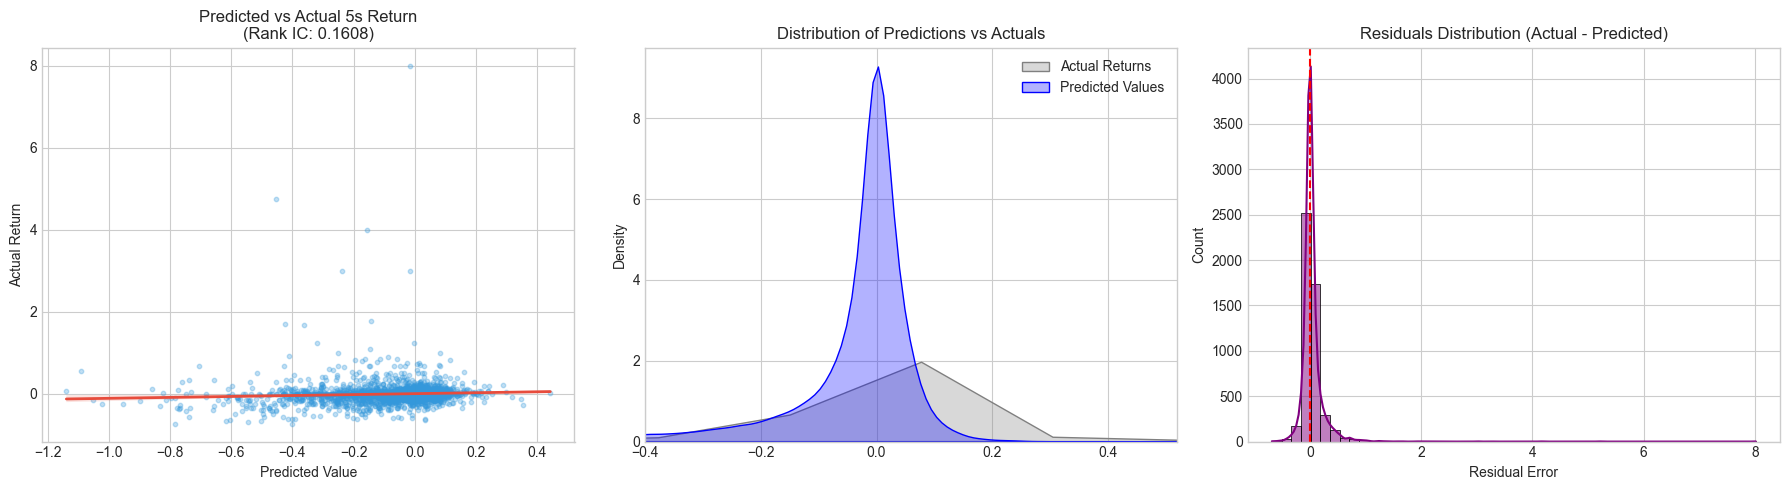

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr

print("📊 正在生成 ML 学术级评估报告...")

# 假设 all_test_preds 和 all_test_targets 是上一段代码跑出来的 list
preds = np.array(all_test_preds)
targets = np.array(all_test_targets)

# ==========================================
# 1. 传统机器学习指标 (The ML Metrics)
# ==========================================
mse = mean_squared_error(targets, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets, preds)
r2 = r2_score(targets, preds)

# ==========================================
# 2. 量化金融核心指标 (The Quant Metrics)
# ==========================================
# 胜率 / 方向准确率 (Hit Rate: 模型看涨/跌，实际也涨/跌的比例)
# ⚠️ 注意：为了严谨，过滤掉真实收益率极其接近 0 的无波澜时段
valid_idx = np.abs(targets) > 1e-5
hit_rate = np.mean(np.sign(preds[valid_idx]) == np.sign(targets[valid_idx]))

# Pearson IC (线性相关性) 与 Rank IC (非线性排序能力)
pearson_ic, _ = pearsonr(preds, targets)
rank_ic, _ = spearmanr(preds, targets)

print("\n" + "="*50)
print("🎓 ML Final Project 核心评估指标汇总 🎓")
print("="*50)
print("[ 传统统计误差 ]")
print(f"  • MSE:  {mse:.6f}")
print(f"  • RMSE: {rmse:.6f}")
print(f"  • MAE:  {mae:.6f}")
print(f"  • R²:   {r2:.4f} (注：高频金融预测中 R² 极低或为负是常态)")
print("\n[ 预测与排序能力 ]")
print(f"  • Pearson IC (线性相关): {pearson_ic:.4f}")
print(f"  • Rank IC (排序相关):    {rank_ic:.4f}")
print(f"  • Directional Accuracy (方向准确率): {hit_rate:.2%}")
print("="*50)

# ==========================================
# 3. 终极学术图表生成 (可以直接截图进 Report)
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图 1：散点回归图 (Scatter & Regression)
# 如果数据太多，随机采样 5000 个点画图防止卡顿
sample_idx = np.random.choice(len(preds), min(5000, len(preds)), replace=False)
sns.regplot(x=preds[sample_idx], y=targets[sample_idx], 
            ax=axes[0], scatter_kws={'alpha':0.3, 's':10, 'color':'#3498db'}, 
            line_kws={'color':'#e74c3c', 'linewidth':2})
axes[0].set_title(f'Predicted vs Actual 5s Return\n(Rank IC: {rank_ic:.4f})')
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Actual Return')

# 图 2：预测分布图 (Distribution Overlay)
sns.kdeplot(targets, ax=axes[1], label='Actual Returns', color='gray', fill=True, alpha=0.3)
sns.kdeplot(preds, ax=axes[1], label='Predicted Values', color='blue', fill=True, alpha=0.3)
axes[1].set_title('Distribution of Predictions vs Actuals')
axes[1].set_xlim([np.percentile(targets, 1), np.percentile(targets, 99)]) # 忽略极值
axes[1].legend()

# 图 3：残差图 (Residuals Plot)
residuals = targets - preds
sns.histplot(residuals[sample_idx], bins=50, kde=True, ax=axes[2], color='purple')
axes[2].axvline(x=0, color='red', linestyle='--')
axes[2].set_title('Residuals Distribution (Actual - Predicted)')
axes[2].set_xlabel('Residual Error')

plt.tight_layout()
plt.show()

💸 开始执行高频策略回测 (Backtest Simulation)...

💰 策 略 回 测 统 计 报 告 💰
📊 总样本数 (60s切片):  61948
🕒 回测时间范围:        2025-12-13 17:03:57+00:00 -> 2025-12-15 03:14:24+00:00
🔫 触发交易次数:        12390 次 (过滤掉了 49558 次噪音)
⚖️ 多空分布:            做多 6195 次 | 做空 6195 次
🎯 扣费后纯胜率 (Win Rate): 48.44%
💵 累计毛收益 (Gross PnL):  237.9260 (模型纯预测能力)
💸 累计手续费 (Trade Cost): 125.7642 (Polymarket taker fee)
💸 累计净收益 (Net PnL):    112.1619 (扣除手续费后的真实利润)
🧾 execution_price 非空样本: 61948 / 61948


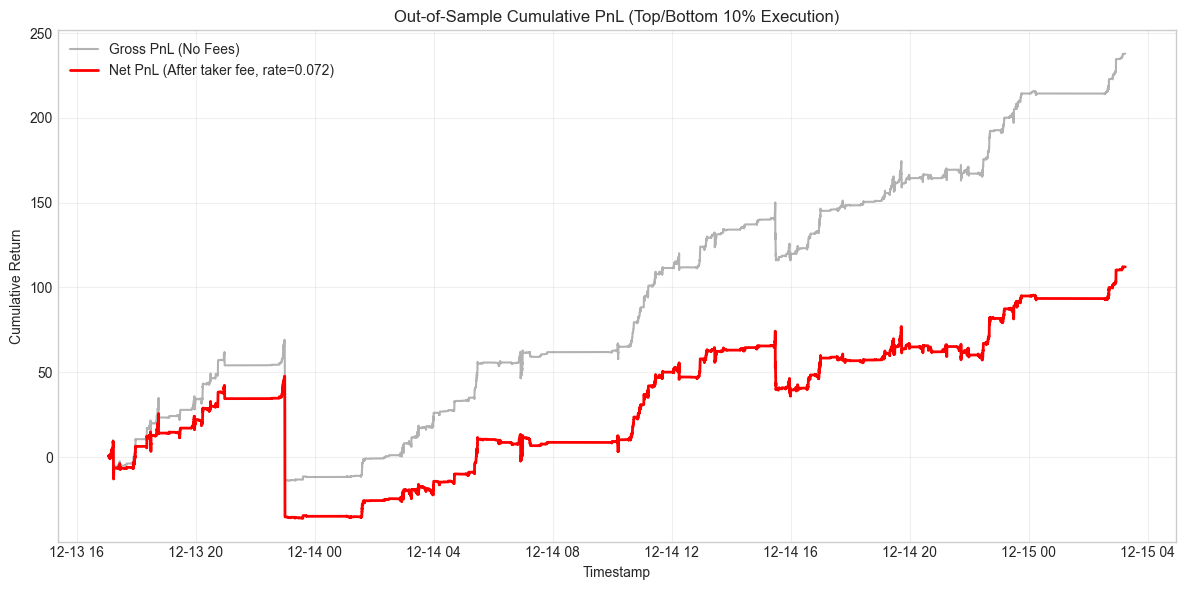

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("💸 开始执行高频策略回测 (Backtest Simulation)...")

if "test_results_df" not in globals():
    raise ValueError("缺少 test_results_df，请先运行盲测推理单元。")

# 1. 使用已经对齐好的盲测结果构造回测 DataFrame
bt_df = test_results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True).copy()
bt_df["execution_price"] = pd.to_numeric(bt_df["execution_price"], errors="coerce")

if bt_df["execution_price"].isna().any():
    missing_count = int(bt_df["execution_price"].isna().sum())
    raise ValueError(
        f"execution_price 存在 {missing_count} 个缺失值。请先确认 ../data/LSTM_DATA_WITH_PRICE.parquet 已正确附上价格。"
    )

# 2. 制定交易规则 (Quantile Thresholding)
# 我们只做模型最确信的极端行情：预测值排名前 10% 做多，后 10% 做空，中间 80% 旁观
UPPER_QUANTILE = 0.90
LOWER_QUANTILE = 0.10

upper_threshold = bt_df["pred_signal"].quantile(UPPER_QUANTILE)
lower_threshold = bt_df["pred_signal"].quantile(LOWER_QUANTILE)

# 3. 生成仓位信号 (Position: 1 做多，-1 做空，0 空仓)
bt_df["position"] = 0
bt_df.loc[bt_df["pred_signal"] >= upper_threshold, "position"] = 1
bt_df.loc[bt_df["pred_signal"] <= lower_threshold, "position"] = -1

# 4. Polymarket taker fee rule
# fee = C * feeRate * p * (1 - p)
# 这里用 taker fee rate = 0.072（按你给的费率表），并把每次触发信号视为成交 1 股
TAKER_FEE_RATE = 0.072
bt_df["shares_traded"] = np.abs(bt_df["position"]).astype(float)

# 5. 计算毛收益与净收益 (Gross & Net PnL)
# 做多: 赚 future_return; 做空: 赚 -future_return
bt_df["gross_pnl"] = bt_df["position"] * bt_df["future_return"]
bt_df["trade_cost"] = (
    bt_df["shares_traded"]
    * TAKER_FEE_RATE
    * bt_df["execution_price"]
    * (1.0 - bt_df["execution_price"])
)
bt_df["net_pnl"] = bt_df["gross_pnl"] - bt_df["trade_cost"]

# 只提取有交易发生的样本进行统计
trades_only = bt_df[bt_df["position"] != 0].copy()
win_rate = (trades_only["net_pnl"] > 0).mean() if len(trades_only) > 0 else np.nan

print("\n" + "="*50)
print("💰 策 略 回 测 统 计 报 告 💰")
print("="*50)
print(f"📊 总样本数 (60s切片):  {len(bt_df)}")
print(f"🕒 回测时间范围:        {bt_df['timestamp'].min()} -> {bt_df['timestamp'].max()}")
print(f"🔫 触发交易次数:        {len(trades_only)} 次 (过滤掉了 {len(bt_df)-len(trades_only)} 次噪音)")
print(f"⚖️ 多空分布:            做多 {sum(trades_only['position']==1)} 次 | 做空 {sum(trades_only['position']==-1)} 次")
print(f"🎯 扣费后纯胜率 (Win Rate): {win_rate:.2%}")
print(f"💵 累计毛收益 (Gross PnL):  {bt_df['gross_pnl'].sum():.4f} (模型纯预测能力)")
print(f"💸 累计手续费 (Trade Cost): {bt_df['trade_cost'].sum():.4f} (Polymarket taker fee)")
print(f"💸 累计净收益 (Net PnL):    {bt_df['net_pnl'].sum():.4f} (扣除手续费后的真实利润)")
print(f"🧾 execution_price 非空样本: {bt_df['execution_price'].notna().sum()} / {len(bt_df)}")
print("="*50)

# 6. 严格按时间排序后的回测结果表
backtest_dataset = bt_df.copy()

# 7. 画资金曲线图
plt.figure(figsize=(12, 6))
plt.plot(bt_df["timestamp"], bt_df["gross_pnl"].cumsum(), label="Gross PnL (No Fees)", color="gray", alpha=0.6)
plt.plot(bt_df["timestamp"], bt_df["net_pnl"].cumsum(), label=f"Net PnL (After taker fee, rate={TAKER_FEE_RATE})", color="red", linewidth=2)
plt.title("Out-of-Sample Cumulative PnL (Top/Bottom 10% Execution)")
plt.xlabel("Timestamp")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
# Time Series CV
print("\n========== 方案 2：TSCV 前向滚动交叉验证 ==========")

# 我们只对 df_base (那 85% 的数据) 做交叉验证
n_splits = 3
tscv = TimeSeriesSplit(n_splits=n_splits)

# 用来存放每一折清洗好的 Train 和 Val，方便后面做 LSTM 切片
cv_folds_data = []

# 由于 df_base 是按时间排序的，TimeSeriesSplit 会安全地按行号往后滑动
for fold, (train_index, val_index) in enumerate(tscv.split(df_base)):
    
    # 1. 获取当前 Fold 的数据切片
    fold_train = df_base.iloc[train_index].copy()
    fold_val   = df_base.iloc[val_index].copy()
    
    # ⚠️ 极其关键：每一个 Fold 都要实例化一个全新的 Scaler！
    # 保证当前的 Train 绝不知道当前 Val 的任何统计信息
    fold_scaler = RobustScaler()
    
    # 2. 拟合与转换 (严格隔离)
    fold_train[feature_cols] = fold_scaler.fit_transform(fold_train[feature_cols])
    fold_val[feature_cols]   = fold_scaler.transform(fold_val[feature_cols])
    
    # 3. 截断护甲
    fold_train[feature_cols] = np.clip(fold_train[feature_cols], -CLIP_VAL, CLIP_VAL)
    fold_val[feature_cols]   = np.clip(fold_val[feature_cols], -CLIP_VAL, CLIP_VAL)
    
    cv_folds_data.append({
        'fold': fold + 1,
        'train': fold_train,
        'val': fold_val,
        'scaler': fold_scaler  # 把这个 Scaler 存下来，如果这个 Fold 表现好，留着以后用
    })
    
    print(f"🔄 Fold {fold + 1}: Train {len(fold_train)} 行 | Val {len(fold_val)} 行")

# 当所有 CV 跑完，你选出了最佳的 Epoch 和超参数后：
# 你需要用整个 df_base (Train+Val合体) 重新训一个最终版模型，去考最初留下的 df_test
print("\n🏆 最终决战准备 (Retrain on Full Base):")
final_scaler = RobustScaler()
df_base[feature_cols] = final_scaler.fit_transform(df_base[feature_cols])
df_test[feature_cols] = final_scaler.transform(df_test[feature_cols])

df_base[feature_cols] = np.clip(df_base[feature_cols], -CLIP_VAL, CLIP_VAL)
df_test[feature_cols] = np.clip(df_test[feature_cols], -CLIP_VAL, CLIP_VAL)



========== 方案 2：TSCV 前向滚动交叉验证 ==========
🔄 Fold 1: Train 95786 行 | Val 95783 行
🔄 Fold 2: Train 191569 行 | Val 95783 行
🔄 Fold 3: Train 287352 行 | Val 95783 行

🏆 最终决战准备 (Retrain on Full Base):


In [16]:
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from scipy.stats import spearmanr
import numpy as np

print("🎯 启动 Optuna 贝叶斯超参数搜索引擎...")
set_seed(SEED)

# ==========================================
# 1. 定义 Optuna 优化目标函数
# ==========================================
def objective(trial):
    """
    Optuna 会无数次调用这个函数。
    每次调用，trial 对象会提供一组全新的、经过贝叶斯大脑思考过的超参数。
    """
    # ----------------------------------
    # 步骤 A：让 Optuna 动态生成超参数
    # ----------------------------------
    # 学习率：在 1e-4 到 5e-3 之间进行对数均匀采样 (Log-uniform)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    # Dropout：在 0.1 到 0.5 之间取值
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    # 隐藏层大小：从候选项里挑
    hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
    # 批次大小：这也是极其影响梯度平滑度的关键参数
    batch_size = trial.suggest_categorical("batch_size", [512, 1024, 2048])
    # 保持 loss 超参数可配置；如果后续想交给 Optuna 搜索，只需在这里覆盖对应字段
    loss_config = dict(HYBRID_TAIL_RANKING_CONFIG)

    # ----------------------------------
    # 步骤 B：使用这组参数，跑完所有的 TSCV 折 (Folds)
    # ----------------------------------
    fold_ics = [] # 记录这一组参数在每一折上的 IC 表现

    # 遍历你之前已经切好并归一化好的 cv_folds_data (共 3 折)
    for fold_data in cv_folds_data:
        fold_idx = fold_data['fold']
        df_train_fold = fold_data['train']
        df_val_fold   = fold_data['val']

        trial_seed_offset = trial.number * 100 + fold_idx
        set_seed(SEED + trial_seed_offset)

        # 1. 临时生成当前折的 3D 张量
        SEQ_LEN = 60
        # (这里复用你之前的 create_lstm_sequences 函数)
        X_tr, y_tr = create_lstm_sequences(df_train_fold, feature_cols, 'Target_5s_Return', SEQ_LEN)
        X_va, y_va = create_lstm_sequences(df_val_fold, feature_cols, 'Target_5s_Return', SEQ_LEN)

        # 2. 封装 DataLoader
        train_loader = DataLoader(
            QuantSequenceDataset(X_tr, y_tr),
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
            generator=make_generator(trial_seed_offset),
        )
        val_loader   = DataLoader(QuantSequenceDataset(X_va, y_va), batch_size=batch_size, shuffle=False)

        # 3. 初始化网络结构
        INPUT_SIZE = len(feature_cols)
        model = AlphaLSTM(INPUT_SIZE, hidden_size, num_layers=1, dropout_prob=dropout).to(device)
        train_criterion, _ = build_hybrid_tail_ranking_loss(y_tr, config=loss_config)
        train_criterion = train_criterion.to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

        # 4. 迷你训练循环 (为了提速，搜索时限制 Epoch，加苛刻的早停)
        SEARCH_EPOCHS = 15 # 搜索时不宜训太久，能看出潜力即可
        best_fold_ic = -999.0
        patience = 3
        patience_cnt = 0

        for epoch in range(SEARCH_EPOCHS):
            # 训练...
            model.train()
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                loss = train_criterion(model(X_batch), y_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            # 验证并算 IC...
            model.eval()
            all_preds, all_targets = [], []
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    preds = model(X_batch)
                    all_preds.extend(preds.cpu().numpy())
                    all_targets.extend(y_batch.cpu().numpy())

            try:
                val_ic, _ = spearmanr(all_preds, all_targets)
            except:
                val_ic = 0.0
            if np.isnan(val_ic): val_ic = 0.0

            # 早停更新
            if val_ic > best_fold_ic:
                best_fold_ic = val_ic
                patience_cnt = 0
            else:
                patience_cnt += 1

            if patience_cnt >= patience:
                break # 这个 Epoch 结束，提早放弃

        # 记录这组参数在这个 Fold 的最高 IC
        fold_ics.append(best_fold_ic)

        # 🔥 Optuna 的黑魔法：剪枝 (Pruning)
        # 如果模型在第 1 折表现极其拉垮 (比如 IC 是负的)，直接中止这组参数的测试！不浪费时间跑后两折了！
        if best_fold_ic < 0.0:
            raise optuna.TrialPruned()

    # ----------------------------------
    # 步骤 C：向 Optuna 汇报综合成绩
    # ----------------------------------
    # 我们看重的是模型在 3 种不同市场环境(3 折) 下的平均表现，这代表了泛化能力
    mean_ic = np.mean(fold_ics)
    return mean_ic


# ==========================================
# 2. 启动贝叶斯搜索器！
# ==========================================
# direction="maximize" 因为我们要最大化 Rank IC
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", study_name="LSTM_Alpha_Search", sampler=sampler)

# 限制跑 20 组试验 (Trials)。因为深度学习慢，先跑 20 组试试水。
print("\n⏳ 开始执行贝叶斯优化任务 (预计耗时较长，去喝杯咖啡吧)...")
study.optimize(objective, n_trials=20)

# ==========================================
# 3. 输出最强王者
# ==========================================
print("\n" + "="*50)
print("🏆 贝叶斯搜索完成！最强参数组合如下：")
print(study.best_params)
print(f"📈 对应的最佳平均 Rank IC: {study.best_value:.4f}")
print("="*50)


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-09 09:51:31,153] A new study created in memory with name: LSTM_Alpha_Search


🎯 启动 Optuna 贝叶斯超参数搜索引擎...

⏳ 开始执行贝叶斯优化任务 (预计耗时较长，去喝杯咖啡吧)...
🔪 开始按 60 步长切割 3D 张量，共发现 143 个独立合约...


100%|██████████| 143/143 [00:00<00:00, 878.97it/s]



✨ 切割大功告成！
📦 喂给 LSTM 的 X 张量形状: (87367, 60, 21) (Batch_Size, 60, 21)
🎯 对应的 y 标签形状: (87367,)
🔪 开始按 60 步长切割 3D 张量，共发现 141 个独立合约...


100%|██████████| 141/141 [00:00<00:00, 2765.31it/s]


...


✨ 切割大功告成！
📦 喂给 LSTM 的 X 张量形状: (262404, 60, 21) (Batch_Size, 60, 21)
🎯 对应的 y 标签形状: (262404,)
🔪 开始按 60 步长切割 3D 张量，共发现 140 个独立合约...


100%|██████████| 140/140 [00:00<00:00, 2716.92it/s]


✨ 切割大功告成！
📦 喂给 LSTM 的 X 张量形状: (87523, 60, 21) (Batch_Size, 60, 21)
🎯 对应的 y 标签形状: (87523,)



[I 2026-04-09 10:34:58,989] Trial 19 finished with value: 0.18399281917098362 and parameters: {'lr': 0.0017141860025422478, 'dropout': 0.26221060577468513, 'hidden_size': 128, 'batch_size': 1024}. Best is trial 17 with value: 0.19114582701089064.



🏆 贝叶斯搜索完成！全局最强超参数诞生 🏆
📈 最高平均 CV IC: 0.1911
🛠️ 最佳超参数组合:
   • lr: 0.002387441460172695
   • dropout: 0.2725790599046439
   • hidden_size: 128
   • batch_size: 1024


In [17]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import RobustScaler
from scipy.stats import spearmanr
from tqdm import tqdm

print("==================================================")
print("👑 终极架构：基础预训练 + 滚动微调 (JIT) + 盲测 👑")
print("==================================================")
set_seed(SEED)

# ==========================================
# 1. 严格的时间轴切分 (Train Base | Recent Val | Test)
# ==========================================
# 我们将 df_base 切分为两部分：远古数据(Train Base) 和 极近期数据(Recent)
val_cutoff = df_base["timestamp"].quantile(0.85)

df_train_base = df_base[df_base["timestamp"] <= val_cutoff].copy()
df_recent     = df_base[df_base["timestamp"] > val_cutoff].copy() # 之前拿来做 Val 的近期数据
df_test_final = df_test.copy()

print(f"📊 兵力部署 -> 远古训练: {len(df_train_base)} | 近期微调(原Val): {len(df_recent)} | 盲测 Test: {len(df_test_final)}")

# ==========================================
# 2. 绝对纯净的归一化护甲
# ==========================================
print("\n🛡️ 正在进行 Scaler 归一化...")
final_scaler = RobustScaler()
CLIP_VAL = 10.0

# 铁律：Scaler 的尺子【只能】由远古训练集决定！
df_train_base[feature_cols] = final_scaler.fit_transform(df_train_base[feature_cols])
df_recent[feature_cols]     = final_scaler.transform(df_recent[feature_cols])
df_test_final[feature_cols] = final_scaler.transform(df_test_final[feature_cols])

# 硬截断防爆
for df_temp in [df_train_base, df_recent, df_test_final]:
    df_temp[feature_cols] = np.clip(df_temp[feature_cols], -CLIP_VAL, CLIP_VAL)

# ==========================================
# 3. 生成最终 3D 张量
# ==========================================
SEQ_LEN = 60
X_base, y_base = create_lstm_sequences(df_train_base, feature_cols, "Target_5s_Return", SEQ_LEN)
X_recent, y_recent = create_lstm_sequences(df_recent, feature_cols, "Target_5s_Return", SEQ_LEN)
X_test, y_test, meta_test_final = create_lstm_sequences(
    df_test_final,
    feature_cols,
    "Target_5s_Return",
    SEQ_LEN,
    return_metadata=True,
    execution_price_col=execution_price_col,
)

# ==========================================
# 4. 召唤 Optuna 认证的最强超参数
# ==========================================
BEST_BATCH  = 1024
BEST_HIDDEN = 128
BEST_DROP   = 0.17066
BEST_LR     = 0.0003058

base_loader_generator = make_generator(1000)
base_loader   = DataLoader(
    QuantSequenceDataset(X_base, y_base),
    batch_size=BEST_BATCH,
    shuffle=True,
    drop_last=True,
    generator=base_loader_generator,
)
recent_loader = DataLoader(QuantSequenceDataset(X_recent, y_recent), batch_size=BEST_BATCH, shuffle=False) # 验证用
test_loader   = DataLoader(QuantSequenceDataset(X_test, y_test), batch_size=2048, shuffle=False)

set_seed(SEED)
model = AlphaLSTM(input_size=len(feature_cols), hidden_size=BEST_HIDDEN, num_layers=1, dropout_prob=BEST_DROP).to(device)
base_loss_config = dict(HYBRID_TAIL_RANKING_CONFIG)
recent_loss_config = dict(HYBRID_TAIL_RANKING_CONFIG)
base_train_criterion, base_loss_stats = build_hybrid_tail_ranking_loss(y_base, config=base_loss_config)
base_train_criterion = base_train_criterion.to(device)
recent_train_criterion, recent_loss_stats = build_hybrid_tail_ranking_loss(y_recent, config=recent_loss_config)
recent_train_criterion = recent_train_criterion.to(device)
eval_criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=BEST_LR, weight_decay=1e-5)
print(format_hybrid_loss_stats(base_loss_stats, base_loss_config, label="Base"))
print(format_hybrid_loss_stats(recent_loss_stats, recent_loss_config, label="Recent"))

# ==========================================
# 阶段 A：基础预训练 (寻找物理规律)
# ==========================================
print("\n" + "🔥"*20)
print("阶段 A：基础预训练 (Pre-Training)")
print("🔥"*20)

EPOCHS = 50
PATIENCE = 5
best_val_ic = -999.0
patience_cnt = 0

for epoch in range(EPOCHS):
    # Train on Base
    model.train()
    for X_batch, y_batch in tqdm(base_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Base Train]", leave=False):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = base_train_criterion(model(X_batch), y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    # Validate on Recent
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in recent_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    val_ic, _ = spearmanr(all_preds, all_targets)
    if np.isnan(val_ic):
        val_ic = 0.0

    print(f"Epoch {epoch+1:02d} | Recent(Val) Rank IC: {val_ic:.4f}")

    if val_ic > best_val_ic:
        best_val_ic = val_ic
        patience_cnt = 0
        torch.save(model.state_dict(), "../models/BASE_LSTM_MODEL.pth")
    else:
        patience_cnt += 1

    if patience_cnt >= PATIENCE:
        print(f"🛑 触发早停，锁定最佳基础模型！")
        break

# ==========================================
# 阶段 B：近期滚动微调 (榨干训练集)
# ==========================================
print("\n" + "⚔️"*20)
print("阶段 B：近期滚动微调 (JIT Fine-Tuning)")
print("⚔️"*20)

# 1. 加载刚才打好底子的模型
model.load_state_dict(torch.load("../models/BASE_LSTM_MODEL.pth", map_location=device))

# 2. 转换身份：把 Recent 数据打包成【可打乱的训练集】
finetune_loader_generator = make_generator(2000)
finetune_loader = DataLoader(
    QuantSequenceDataset(X_recent, y_recent),
    batch_size=BEST_BATCH,
    shuffle=True,
    generator=finetune_loader_generator,
)

# 3. ⚠️ 核心奥义：学习率降维打击！
# 此时模型已经懂了物理规律，我们只需要它稍微向最近的盘口靠拢
FINETUNE_LR = BEST_LR * 0.1
finetune_optimizer = torch.optim.Adam(model.parameters(), lr=FINETUNE_LR, weight_decay=1e-5)

# 只跑极少的 Epoch (比如 3 轮)，防止破坏之前好不容易学到的泛化基底
FINETUNE_EPOCHS = 3
model.train() # 再次开启训练模式

for epoch in range(FINETUNE_EPOCHS):
    epoch_loss = 0.0
    for X_batch, y_batch in tqdm(finetune_loader, desc=f"Fine-Tuning {epoch+1}/{FINETUNE_EPOCHS}"):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        finetune_optimizer.zero_grad()
        loss = recent_train_criterion(model(X_batch), y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        finetune_optimizer.step()
        epoch_loss += loss.item()
    print(f"   🎯 Finetune Epoch {epoch+1} Hybrid Loss: {epoch_loss/len(finetune_loader):.6f}")

# 保存最终吸收了 100% 训练数据的神级模型
torch.save(model.state_dict(), "../models/ULTIMATE_FINETUNED_MODEL.pth")
print("✨ 临阵磨枪完成！模型的‘近期偏好’已被彻底唤醒！")

# ==========================================
# 阶段 C：终极盲测 (Test Inference)
# ==========================================
print("\n" + "="*50)
print("⚖️ 进 入 终 极 盲 测 (TEST INFERENCE)")
print("="*50)

model.eval()
all_test_preds, all_test_targets = [], []
test_loss = 0.0

with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc="[Testing]"):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        test_loss += eval_criterion(preds, y_batch).item()

        all_test_preds.extend(preds.cpu().numpy())
        all_test_targets.extend(y_batch.cpu().numpy())

avg_test_mae = test_loss / len(test_loader)
test_ic, p_value = spearmanr(all_test_preds, all_test_targets)

test_results_df = meta_test_final.copy()
test_results_df["pred_signal"] = np.asarray(all_test_preds, dtype=np.float32)
test_results_df["future_return"] = np.asarray(all_test_targets, dtype=np.float32)
raw_test_results_are_chronological = test_results_df["timestamp"].is_monotonic_increasing
test_results_df = test_results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True)

print(f"🕒 原始序列输出是否已经严格按时间排序: {raw_test_results_are_chronological}")
if test_results_df["execution_price"].isna().all():
    print("⚠️ execution_price 当前全为空，因为 LSTM_DATA.parquet 没有保留价格列。")
else:
    print(f"💵 execution_price 非空样本: {test_results_df['execution_price'].notna().sum()} / {len(test_results_df)}")

print("\n" + "🌟"*25)
print("🏆 终 极 考 卷 成 绩 (经微调强化) 🏆")
print("🌟"*25)
print(f"📉 Test MAE:   {avg_test_mae:.6f}")
print(f"📈 Test Rank IC: {test_ic:.4f}")
print(f"🎯 P-value:      {p_value:.4e}")
print("="*50)

if test_ic > 0.20:
    print("\n🚀 完美收官！微调策略成功，模型捕获了最新的 Alpha 动能！")
else:
    print("\n🤔 微调后效果仍有提升空间，建议继续优化 loss 与特征工程。")


👑 终极架构：基础预训练 + 滚动微调 (JIT) + 盲测 👑
📊 兵力部署 -> 远古训练: 325664 | 近期微调(原Val): 57471 | 盲测 Test: 67612

🛡️ 正在进行 Scaler 归一化...
🔪 开始按 60 步长切割 3D 张量，共发现 480 个独立合约...


100%|██████████| 480/480 [00:00<00:00, 1871.86it/s]



✨ 切割大功告成！
📦 喂给 LSTM 的 X 张量形状: (297344, 60, 21) (Batch_Size, 60, 21)
🎯 对应的 y 标签形状: (297344,)
🔪 开始按 60 步长切割 3D 张量，共发现 83 个独立合约...


100%|██████████| 83/83 [00:00<00:00, 2723.98it/s]



✨ 切割大功告成！
📦 喂给 LSTM 的 X 张量形状: (52574, 60, 21) (Batch_Size, 60, 21)
🎯 对应的 y 标签形状: (52574,)
🔪 开始按 60 步长切割 3D 张量，共发现 96 个独立合约...


...

   🎯 Finetune Epoch 2 MAE: 0.062024


Fine-Tuning 3/3: 100%|██████████| 52/52 [00:02<00:00, 22.36it/s]


   🎯 Finetune Epoch 3 MAE: 0.062123
✨ 临阵磨枪完成！模型的‘近期偏好’已被彻底唤醒！

⚖️ 进 入 终 极 盲 测 (TEST INFERENCE)


[Testing]: 100%|██████████| 31/31 [00:01<00:00, 23.64it/s]


🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
🏆 终 极 考 卷 成 绩 (经微调强化) 🏆
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
📉 Test MAE:   0.098460
📈 Test Rank IC: 0.1382
🎯 P-value:      7.5196e-262
